# Time Series Analysis

## 1. Introduction to Time Series Data

Time series data is data collected over a sequence of time intervals such as daily, weekly, monthly, or yearly observations.

### Examples of Time Series Data
- Stock market prices
- Sales records
- Weather data
- Temperature readings
- Website traffic

### Characteristics of Time Series Data

1. **Chronological Order**  
   Data points are arranged according to time from past to present.

2. **Sequential Data**  
   Each observation depends on the sequence in which it occurs.

3. **Temporal Components**  
   Time series data often contains patterns such as trends, seasonality, and cycles.

4. **Constant Frequency**  
   Data is usually collected at regular intervals like hourly, daily, or monthly.

5. **Dynamic Nature**  
   Values change over time due to internal or external factors.

---

# 2. Time Series Analysis

Time series analysis is a statistical technique used to extract meaningful insights, identify patterns, and understand trends from time-based data.

It helps in:
- Understanding past behavior
- Forecasting future values
- Detecting trends and seasonal patterns

---

# 3. Time Series Decomposition

Time series decomposition breaks data into multiple components for better analysis.

## Components of Time Series

1. **Trend**  
   The long-term upward or downward movement in data.

2. **Seasonality**  
   Repeating patterns that occur at fixed and regular intervals.

3. **Cyclic Component**  
   Repeating patterns that occur over irregular time periods.

   - **Economic Cycles**  
     Changes caused by inflation, recession, or economic growth.

   - **Business Cycles**  
     Variations in business performance due to market conditions.

4. **Noise (Irregular Component)**  
   Random fluctuations or sudden spikes that cannot be predicted.

---

# 4. Types of Decomposition

## Additive Decomposition

Used when seasonal variations remain relatively constant over time.

$y_t = T_t + S_t + E_t$



Where:
- \( y_t \) = Observed value
- \( T_t \) = Trend component
- \( S_t \) = Seasonal component
- \( E_t \) = Error/Noise component

---

## Multiplicative Decomposition

Used when seasonal variations increase or decrease proportionally with the trend.

$y_t = T_t \times S_t \times E_t$
Where:
- \( y_t \) = Observed value
- \( T_t \) = Trend component
- \( S_t \) = Seasonal component
- \( E_t \) = Error/Noise component

![](./images/img1.png)

In [1]:
#Imports
import yfinance as yf
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [9]:
import yfinance as yf

stock_data = yf.download("AAPL", start="2024-01-01", end="2024-08-01")
stock_data.columns = stock_data.columns.droplevel(1)

print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Date                                                                
2024-01-02  183.562195  186.330858  181.831782  185.055288  82488700
2024-01-03  182.187759  183.799520  181.376930  182.158096  58414500
2024-01-04  179.873932  181.040717  178.855462  180.111236  71983600
2024-01-05  179.152100  180.714417  178.153410  179.953046  62379700
2024-01-08  183.483063  183.522623  179.468508  180.051901  59144500


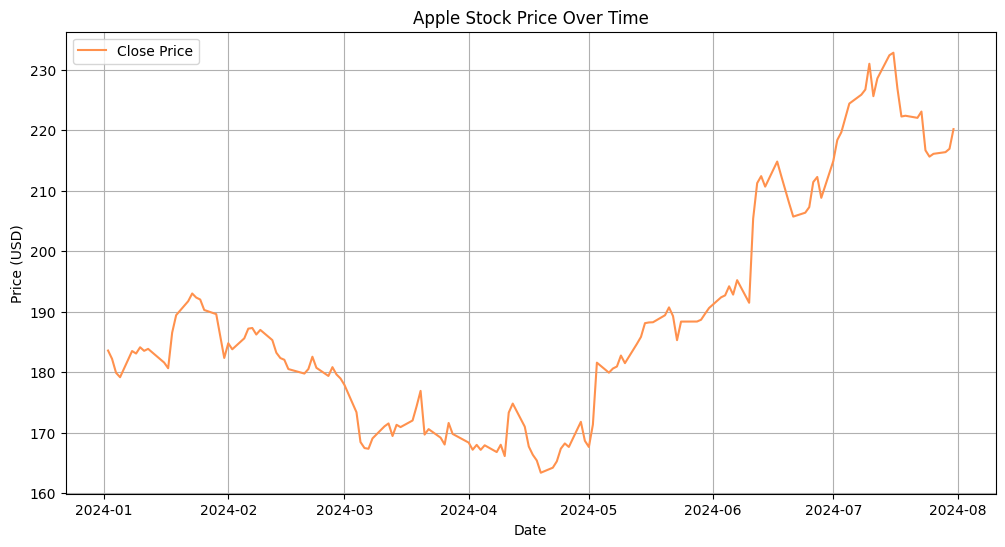

In [10]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data["Close"], label = "Close Price", color="#FF914D")
plt.title("Apple Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Decomposition Using Classic Method

Classical decomposition is a traditional approach where a time series is split into its main components:
- Trend
- Seasonality
- Residual (Noise)

It assumes that these components combine in either an additive or multiplicative form.

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model="additive", period=30)

In [18]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_Additive = decomposition_additive.resid

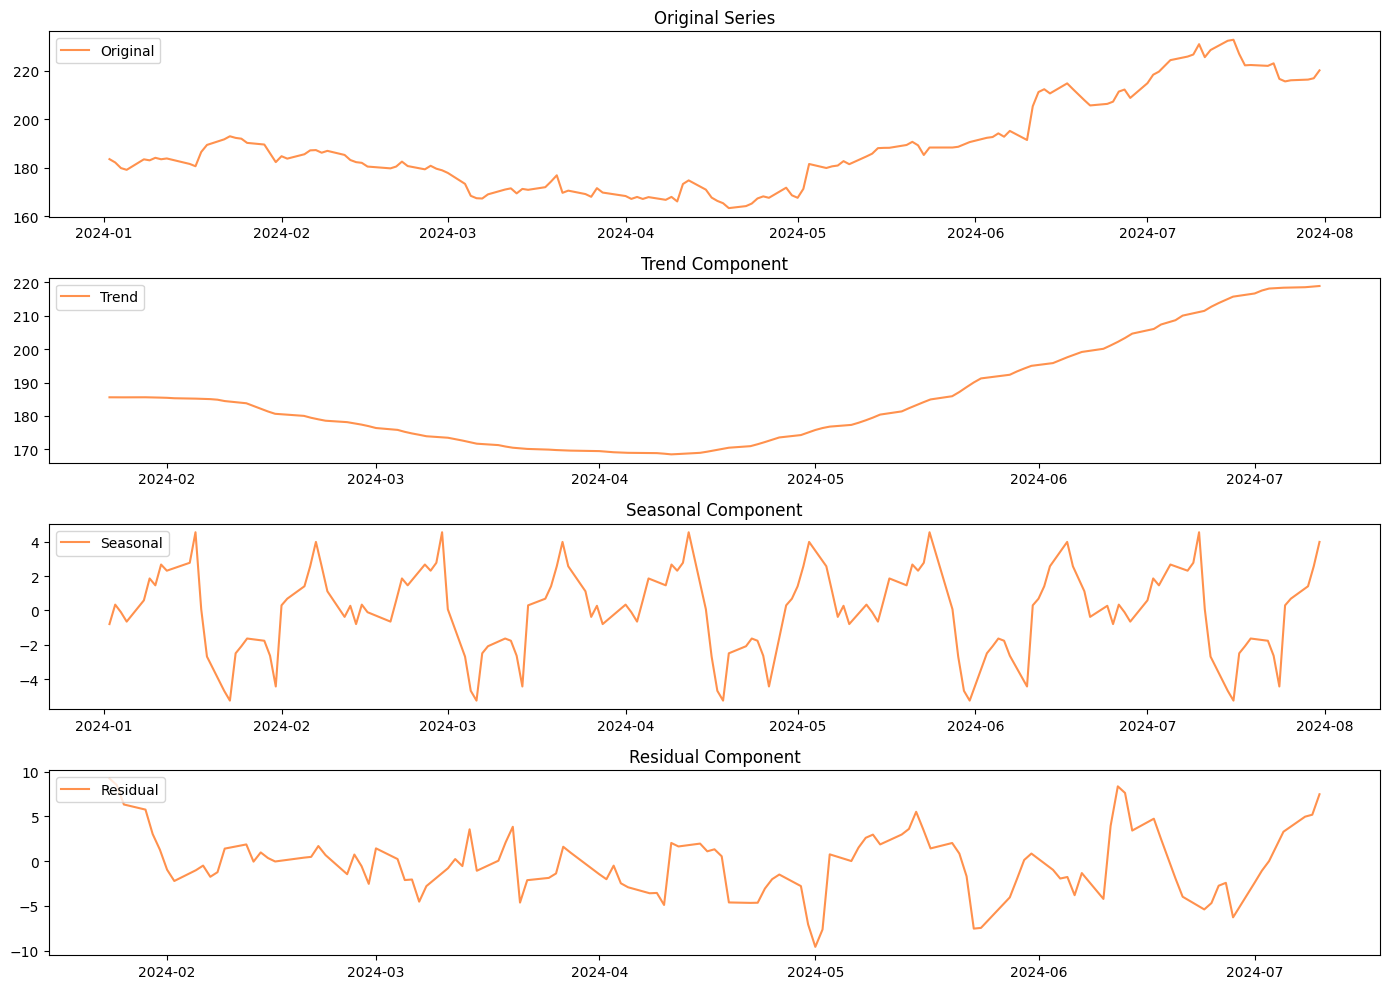

In [19]:
fig, ax = plt.subplots(4, 1, figsize=(14, 10))

# 1. Original series
ax[0].plot(stock_data['Close'], label="Original", color="#FF914D")
ax[0].legend(loc='upper left')
ax[0].set_title("Original Series")

# 2. Trend
ax[1].plot(trend_additive, label="Trend", color="#FF914D")
ax[1].legend(loc='upper left')
ax[1].set_title("Trend Component")

# 3. Seasonal
ax[2].plot(seasonal_additive, label="Seasonal", color="#FF914D")
ax[2].legend(loc='upper left')
ax[2].set_title("Seasonal Component")

# 4. Residual
ax[3].plot(residual_Additive, label="Residual", color="#FF914D")
ax[3].legend(loc='upper left')
ax[3].set_title("Residual Component")

plt.tight_layout()
plt.show()

# Decomposition Using LOESS Method

LOESS decomposition uses **Locally Estimated Scatterplot Smoothing (LOESS)** to extract trend and seasonal components more flexibly.

It is especially useful when:
- The data contains **a lot of noise or outliers**
- The trend is **non-linear or complex**
- Classical decomposition fails to capture smooth patterns accurately

LOESS provides a **smoothed representation of the trend and seasonality**, making it more robust for real-world noisy datasets.

Rule:
1. For additive data use STL / LOESS Method
2. For multiplicative use classical Method

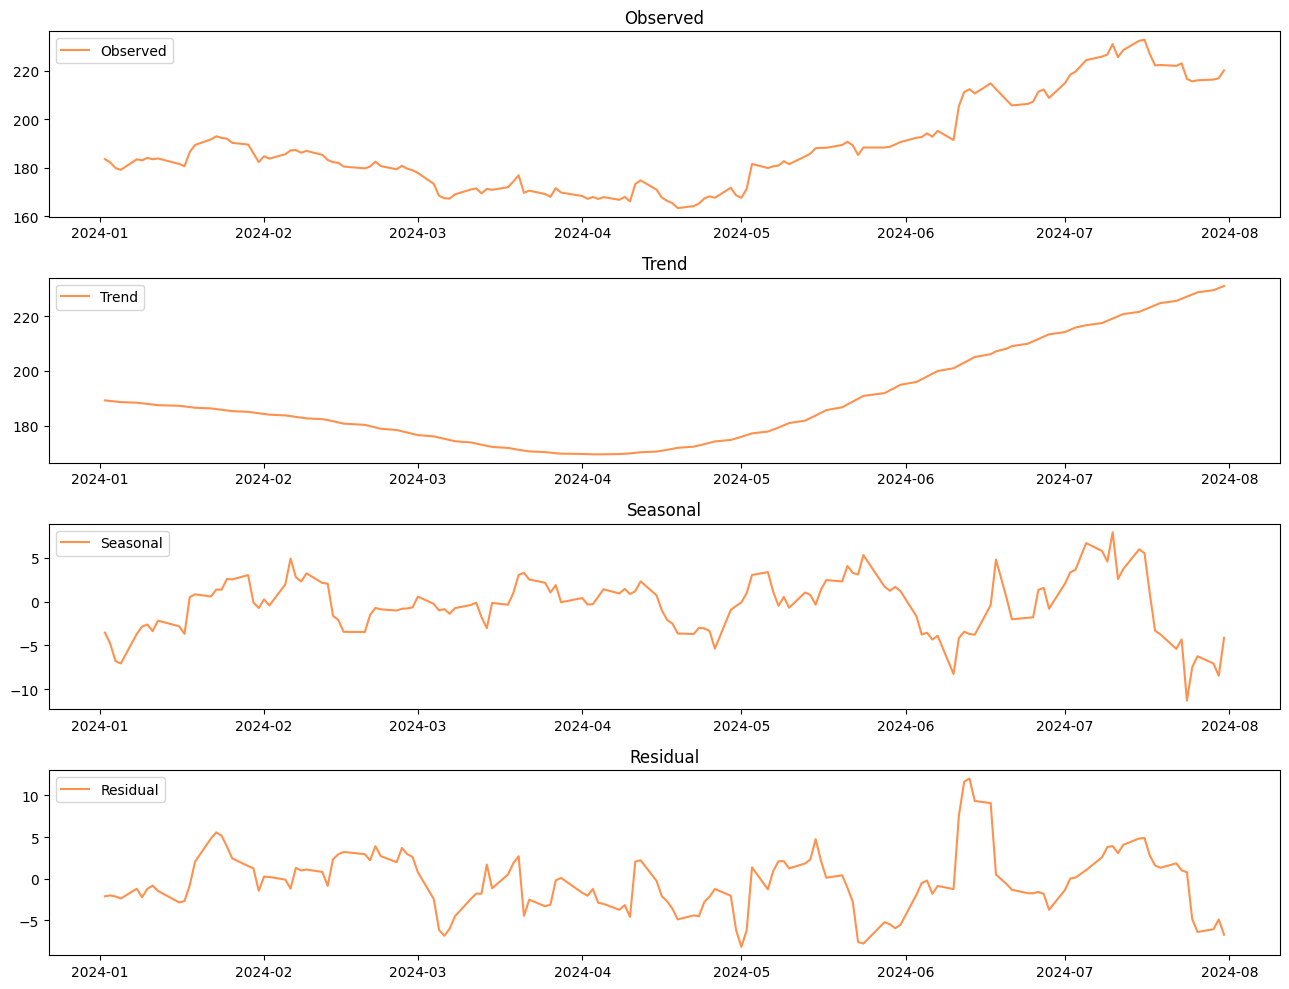

In [23]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

stl = STL(stock_data['Close'], period=30)
result = stl.fit()

fig, ax = plt.subplots(4, 1, figsize=(13, 10))

# Observed
ax[0].plot(result.observed, label='Observed', color='#FF914D')
ax[0].legend(loc='upper left')
ax[0].set_title("Observed")

# Trend
ax[1].plot(result.trend, label='Trend', color='#FF914D')
ax[1].legend(loc='upper left')
ax[1].set_title("Trend")

# Seasonal
ax[2].plot(result.seasonal, label='Seasonal', color='#FF914D')
ax[2].legend(loc='upper left')
ax[2].set_title("Seasonal")

# Residual
ax[3].plot(result.resid, label='Residual', color='#FF914D')
ax[3].legend(loc='upper left')
ax[3].set_title("Residual")

plt.tight_layout()
plt.show()

# 5. Stationarity

A time series is said to be **stationary** if its statistical properties such as **mean, variance, and autocorrelation** remain constant over time.

---

## Why Stationarity is Important

Stationarity is important because most forecasting models assume that the statistical properties of the data remain constant over time.

This is useful because:
- It simplifies modeling and analysis
- It improves the reliability of predictions
- It ensures models trained on past data remain valid for future forecasting

---

## Types of Stationarity

### 1. Weak Stationarity (Covariance Stationarity)

A time series is weakly stationary if:
- Mean is constant over time  
- Variance is constant over time  
- Autocorrelation depends only on lag (not on time itself)  
- The joint distribution may still change over time  

It is commonly used for short-term time series modeling.

---

### 2. Strict Stationarity

A time series is strictly stationary if:
- All statistical properties remain unchanged under time shifts  
- The entire joint distribution remains invariant when shifted in time  

It is used for modeling the full distribution of the data.

In simple terms:
> Strict stationarity means the probabilistic structure of the series does not change over time.

It is a stronger condition than weak stationarity.

---

![Stationarity Example](./images/img2.png)

---

# Tests for Stationarity

## 1. Augmented Dickey-Fuller (ADF) Test

Used to check the presence of a **unit root**, which indicates non-stationarity (trend).

### Hypothesis:
- **H₀ (Null):** Data is non-stationary  
- **H₁ (Alternative):** Data is stationary  

### Decision Criteria:
- If **p-value < α (significance level)** → Reject H₀ → Stationary  
- If **ADF statistic < Critical value** → Reject H₀ → Stationary  

---

## 2. KPSS Test

KPSS assumes the data is stationary and tests for deviations from it.

It fits a constant mean model and examines the variance of the cumulative sum of residuals.

### Hypothesis:
- **H₀ (Null):** Data is stationary  
- **H₁ (Alternative):** Data is non-stationary  

---

### Interpretation:
- If p-value is small → reject H₀ → data is non-stationary  
- If p-value is large → fail to reject H₀ → data is stationary